# Daphnet FoG Dataset - Exploratory Data Analysis (EDA)

**Dataset Information:**
- Source: Laboratory for Gait and Neurodynamics, Tel Aviv Sourasky Medical Center
- Sensors: 3 3D accelerometers at 64 Hz
- Location: Ankle (shank), Thigh (thigh), Trunk (trunk)
- Subjects: 10 patients with Parkinson's (S01-S10)
- Original annotations: 0=Not experiment, 1=Walking without freeze, 2=Freeze

This notebook focuses on initial data exploration and understanding class imbalance.

In [1]:
# Necessary imports
import sys
from pathlib import Path

# Add root directory to path
# Desde archive/ necesitamos subir 3 niveles: archive -> daphnet_dataset -> examples -> raíz
root_path = Path.cwd().parent.parent.parent
sys.path.insert(0, str(root_path))

from loaders import DaphnetDatasetLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut

sns.set_style('whitegrid')
%matplotlib inline

/Users/davidperez/Documents/tesis/Seminario_II/loaders/DaphnetReader.py:53: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


Load dataframe

In [2]:
# Ruta al dataset (desde archive/ subimos a raíz del proyecto)
loader = DaphnetDatasetLoader('../../../Datasets/Daphnet fog/dataset')

In [8]:
loader.load_all_data()
df = loader.save_dataset('daphnet_complete_dataset', formats=['csv'])

📁 Encontrados 17 archivos
📊 Cargando datos del dataset Daphnet...



Cargando archivos: 100%|██████████| 17/17 [00:23<00:00,  1.36s/it]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: DaphnetDatasetLoader

📊 Información General:
   Dimensiones: (1917887, 16)
   Filas: 1,917,887
   Columnas: 16
   Memoria: 327.40 MB

👥 Sujetos: 10
📁 Archivos: 17

🚨 Episodios de FoG:
   Muestras con FoG: 110,785 (5.78%)
   Muestras sin FoG: 1,807,102 (94.22%)

💾 Guardando dataset DaphnetDatasetLoader...
   📊 Tamaño: (1917887, 16)
   💽 Memoria: 327.40 MB

✅ CSV guardado: daphnet_complete_dataset.csv (131.39 MB)

🎉 Dataset guardado exitosamente en 1 formato(s)


In [9]:
loader.print_summary()


RESUMEN DEL DATASET: DaphnetDatasetLoader

📊 Información General:
   Dimensiones: (1917887, 16)
   Filas: 1,917,887
   Columnas: 16
   Memoria: 327.40 MB

👥 Sujetos: 10
📁 Archivos: 17

🚨 Episodios de FoG:
   Muestras con FoG: 110,785 (5.78%)
   Muestras sin FoG: 1,807,102 (94.22%)



In [10]:
# Dataframe information
df.info()

AttributeError: 'list' object has no attribute 'info'

In [ ]:

df = df[df['annotation'] != 0].reset_index(drop=True)

print(df['annotation'].value_counts().sort_index())
print(f"\nPercentages:")
print(df['annotation'].value_counts(normalize=True).sort_index() * 100)

annotation
1    1030050
2     110785
Name: count, dtype: int64

Porcentajes:
annotation
1    90.28913
2     9.71087
Name: proportion, dtype: float64


In [ ]:
# Descriptive statistics
df.describe()

,time_ms,ankle_acc_forward,ankle_acc_vertical,ankle_acc_lateral,thigh_acc_forward,thigh_acc_vertical,thigh_acc_lateral,trunk_acc_forward,trunk_acc_vertical,trunk_acc_lateral,annotation,subject_id,run_id,time_s
count,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06,1.917887e+06
mean,1.068270e+06,-5.121767e+01,8.269251e+02,5.814148e+01,-3.909704e+01,6.078131e+02,-3.851133e+01,4.953984e+01,7.706783e+02,-1.105940e+02,6.526036e-01,5.323289e+00,1.269234e+00,1.068270e+03
std,7.525219e+05,5.241233e+02,4.924929e+02,5.544153e+02,5.356087e+02,4.343619e+02,4.813304e+02,2.822827e+02,4.180118e+02,4.095316e+02,5.850132e-01,2.838412e+00,5.196389e-01,7.525219e+02
min,1.500000e+01,-3.123400e+04,-3.276300e+04,-3.148800e+04,-2.184600e+04,-2.967300e+04,-2.431800e+04,-5.019000e+03,-3.400000e+03,-4.786000e+03,0.000000e+00,1.000000e+00,1.000000e+00,1.500000e-02
25%,4.407030e+05,-2.120000e+02,7.740000e+02,6.900000e+01,-2.810000e+02,2.590000e+02,-9.000000e+01,-8.700000e+01,8.000000e+02,-1.940000e+02,0.000000e+00,3.000000e+00,1.000000e+00,4.407030e+02
50%,9.297030e+05,-2.000000e+01,9.700000e+02,2.070000e+02,-2.700000e+01,6.750000e+02,9.000000e+01,3.800000e+01,9.610000e+02,-3.800000e+01,1.000000e+00,5.000000e+00,1.000000e+00,9.297030e+02
75%,1.596812e+06,1.210000e+02,1.019000e+03,3.260000e+02,1.900000e+02,9.620000e+02,2.320000e+02,1.940000e+02,1.009000e+03,1.060000e+02,1.000000e+00,8.000000e+00,1.000000e+00,1.596812e+03
max,3.058390e+06,3.072500e+04,3.200200e+04,3.174400e+04,2.662500e+04,3.259800e+04,2.841800e+04,6.707000e+03,2.429800e+04,4.339000e+03,2.000000e+00,1.000000e+01,3.000000e+00,3.058390e+03


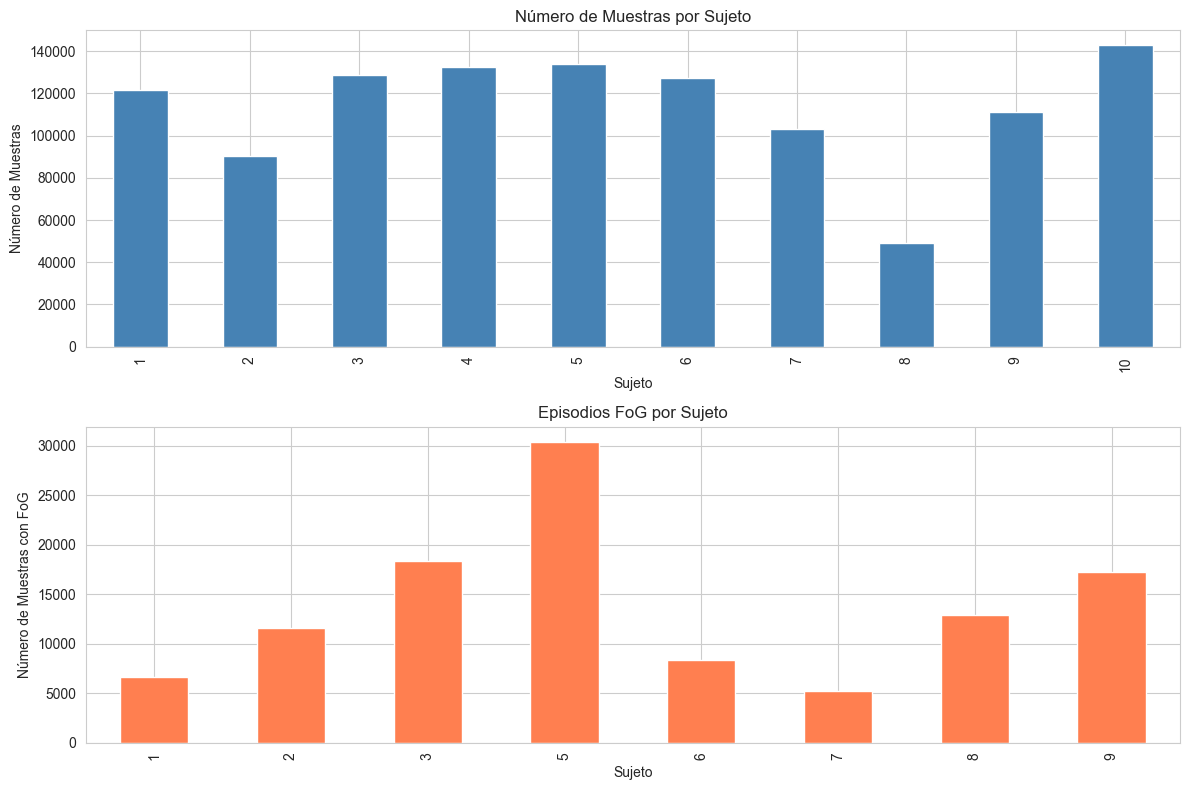

In [ ]:
# Distribution by subject
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Samples per subject
df['subject_id'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Samples per Subject')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Number of Samples')

# FoG by subject
fog_by_subject = df[df['annotation'] == 2].groupby('subject_id').size()
fog_by_subject.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('FoG Episodes per Subject')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Number of Samples with FoG')

plt.tight_layout()
plt.show()

---
## Observations and Recommendations

### Phenomenon: Class Imbalance + Subject Variability
The analysis reveals:
- FoG episodes represent only ~5-20% of total samples per subject
- Subject 5 has 6x more FoG episodes than Subject 1
- Subject 8 has half the data compared to other subjects

### Recommended Treatment Strategies:
1. **Class weights** - Penalize misclassification of minority class (FoG) during training
2. **SMOTE/oversampling** - Synthetically generate FoG samples
3. **Proper metrics** - Use F1-score, Recall, Balanced Accuracy (not just accuracy)
4. **Stratified reporting** - Report per-subject performance to identify difficult cases
5. **Focal Loss** - For deep learning; focuses on hard-to-classify examples

---
## EDA Summary

Completed exploratory data analysis:

1. ✅ **Dataset loaded** - 10 subjects with Parkinson's disease
2. ✅ **Data structure analyzed** - 3 accelerometers × 3 axes = 9 features
3. ✅ **Class imbalance identified** - FoG is minority class (~5-20%)
4. ✅ **Subject variability assessed** - Different FoG patterns across subjects

**Next step:** `daphnet_segmentation.ipynb` - Create binary/multiclass labels and LOSO splits